
## Flickr8k Image Captioning 


In [1]:
import os
import re
import time
import json
import random
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

In [2]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
BATCH_SIZE = 16
BASE_EPOCHS = 3
ABLATION_EPOCHS = 2
IMAGE_SIZE = 224

# Optional runtime caps. Set to integers like 12000/1500/1500 if needed.
MAX_TRAIN_ROWS = None
MAX_VAL_ROWS = None
MAX_TEST_ROWS = None

print("Device:", DEVICE)

Device: cuda


In [3]:
def find_flickr8k_root() -> Path:
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for child in kaggle_input.iterdir():
            if child.is_dir() and "flickr" in child.name.lower():
                return child

    try:
        import kagglehub

        return Path(kagglehub.dataset_download("adityajn105/flickr8k"))
    except Exception as exc:
        raise FileNotFoundError(
            "Could not locate Flickr8k. Add the dataset to the Kaggle notebook or use kagglehub."
        ) from exc


def find_images_dir(root: Path) -> Path:
    for path in root.rglob("*"):
        if path.is_dir() and path.name.lower() in {"images", "image", "flickr8k_images"}:
            return path
    raise FileNotFoundError("Could not find image folder in Flickr8k dataset.")


def find_captions_file(root: Path) -> Path:
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in {".txt", ".csv"} and "caption" in path.name.lower():
            return path
    raise FileNotFoundError("Could not find captions file in Flickr8k dataset.")


DATA_ROOT = find_flickr8k_root()
IMAGES_DIR = find_images_dir(DATA_ROOT)
CAPTIONS_FILE = find_captions_file(DATA_ROOT)

print("Dataset root:", DATA_ROOT)
print("Images dir:", IMAGES_DIR)
print("Captions file:", CAPTIONS_FILE)

Dataset root: /kaggle/input/datasets/adityajn105/flickr8k
Images dir: /kaggle/input/datasets/adityajn105/flickr8k/Images
Captions file: /kaggle/input/datasets/adityajn105/flickr8k/captions.txt


In [4]:
def read_captions_file(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        lower = line.lower()
        if lower.startswith("image") and ("caption" in lower or "|" in lower or "," in lower):
            continue

        if "|" in line:
            parts = [part.strip() for part in line.split("|")]
            if len(parts) >= 3:
                rows.append((parts[0], parts[-1]))
                continue

        if "\t" in line:
            parts = [part.strip() for part in line.split("\t")]
            if len(parts) >= 2:
                rows.append((parts[0].split("#")[0], parts[-1]))
                continue

        if "," in line:
            image_name, caption_text = line.split(",", 1)
            rows.append((image_name.strip().split("#")[0], caption_text.strip()))

    if not rows:
        raise ValueError("No caption rows could be parsed from the Flickr8k captions file.")

    df = pd.DataFrame(rows, columns=["image_name", "caption"])
    df["image_path"] = df["image_name"].apply(lambda x: str(IMAGES_DIR / x))
    df = df[df["image_path"].apply(lambda x: Path(x).exists())].reset_index(drop=True)
    return df


captions_df = read_captions_file(CAPTIONS_FILE)
print("Caption rows:", len(captions_df))
print("Unique images:", captions_df["image_name"].nunique())
captions_df.head()

Caption rows: 40455
Unique images: 8091


,image_name,caption,image_path
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,/kaggle/input/datasets/adityajn105/flickr8k/Im...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,/kaggle/input/datasets/adityajn105/flickr8k/Im...
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,/kaggle/input/datasets/adityajn105/flickr8k/Im...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,/kaggle/input/datasets/adityajn105/flickr8k/Im...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,/kaggle/input/datasets/adityajn105/flickr8k/Im...


In [5]:
def split_by_image(df: pd.DataFrame, train_ratio: float = 0.8, val_ratio: float = 0.1):
    image_names = sorted(df["image_name"].unique().tolist())
    random.shuffle(image_names)

    n_total = len(image_names)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_images = set(image_names[:n_train])
    val_images = set(image_names[n_train:n_train + n_val])
    test_images = set(image_names[n_train + n_val:])

    train_df = df[df["image_name"].isin(train_images)].reset_index(drop=True)
    val_df = df[df["image_name"].isin(val_images)].reset_index(drop=True)
    test_df = df[df["image_name"].isin(test_images)].reset_index(drop=True)
    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_image(captions_df)

if MAX_TRAIN_ROWS is not None:
    train_df = train_df.iloc[:MAX_TRAIN_ROWS].reset_index(drop=True)
if MAX_VAL_ROWS is not None:
    val_df = val_df.iloc[:MAX_VAL_ROWS].reset_index(drop=True)
if MAX_TEST_ROWS is not None:
    test_df = test_df.iloc[:MAX_TEST_ROWS].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

32360 4045 4050


In [6]:
PAD_TOKEN = "<PAD>"
START_TOKEN = "<START>"
END_TOKEN = "<END>"
UNK_TOKEN = "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]


def normalize_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_df["caption_clean"] = train_df["caption"].apply(normalize_caption)
val_df["caption_clean"] = val_df["caption"].apply(normalize_caption)
test_df["caption_clean"] = test_df["caption"].apply(normalize_caption)


class Vocabulary:
    def __init__(self, texts: List[str], min_freq: int = 2):
        counter = Counter()
        for text in texts:
            counter.update(text.split())

        self.itos = list(SPECIAL_TOKENS)
        for token, freq in sorted(counter.items()):
            if freq >= min_freq and token not in SPECIAL_TOKENS:
                self.itos.append(token)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

    @property
    def pad_idx(self):
        return self.stoi[PAD_TOKEN]

    @property
    def start_idx(self):
        return self.stoi[START_TOKEN]

    @property
    def end_idx(self):
        return self.stoi[END_TOKEN]

    @property
    def unk_idx(self):
        return self.stoi[UNK_TOKEN]

    def encode(self, text: str) -> torch.Tensor:
        tokens = [START_TOKEN] + text.split() + [END_TOKEN]
        ids = [self.stoi.get(tok, self.unk_idx) for tok in tokens]
        return torch.tensor(ids, dtype=torch.long)

    def decode(self, ids: List[int]) -> str:
        words = []
        for idx in ids:
            token = self.itos[int(idx)]
            if token == END_TOKEN:
                break
            if token in SPECIAL_TOKENS:
                continue
            words.append(token)
        return " ".join(words)

    def __len__(self):
        return len(self.itos)


vocab = Vocabulary(train_df["caption_clean"].tolist(), min_freq=2)
print("Vocabulary size:", len(vocab))

Vocabulary size: 4697


In [7]:
train_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class Flickr8kCaptionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Vocabulary, transform):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        caption_ids = self.vocab.encode(row["caption_clean"])
        return {
            "image": image,
            "caption_ids": caption_ids,
            "caption_text": row["caption_clean"],
            "image_path": row["image_path"],
        }


def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    captions = [item["caption_ids"] for item in batch]
    padded = pad_sequence(captions, batch_first=True, padding_value=vocab.pad_idx)
    texts = [item["caption_text"] for item in batch]
    paths = [item["image_path"] for item in batch]
    return {
        "images": images,
        "captions": padded,
        "caption_texts": texts,
        "image_paths": paths,
    }


train_dataset = Flickr8kCaptionDataset(train_df, vocab, train_transform)
val_dataset = Flickr8kCaptionDataset(val_df, vocab, eval_transform)
test_dataset = Flickr8kCaptionDataset(test_df, vocab, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn,
)

In [8]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_dim: int, fine_tune: bool = False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT
        backbone = models.resnet50(weights=weights)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.project = nn.Linear(backbone.fc.in_features, embed_dim)
        self.relu = nn.ReLU()
        self.set_fine_tune(fine_tune)

    def set_fine_tune(self, fine_tune: bool):
        for param in self.feature_extractor.parameters():
            param.requires_grad = fine_tune

    def forward(self, images: torch.Tensor):
        features = self.feature_extractor(images).flatten(1)
        return self.relu(self.project(features))


class DecoderRNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, decoder_type: str = "rnn", dropout: float = 0.0):
        super().__init__()
        self.decoder_type = decoder_type
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab.pad_idx)
        if decoder_type == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif decoder_type == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError(f"Unsupported decoder type: {decoder_type}")

        self.hidden_init = nn.Linear(embed_dim, hidden_dim)
        self.cell_init = nn.Linear(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def init_state(self, image_features: torch.Tensor):
        hidden = self.hidden_init(image_features).unsqueeze(0).contiguous()
        if self.decoder_type == "lstm":
            cell = self.cell_init(image_features).unsqueeze(0).contiguous()
            return hidden, cell
        return hidden

    def forward(self, image_features: torch.Tensor, captions: torch.Tensor):
        decoder_inputs = captions[:, :-1]
        embedded = self.embedding(decoder_inputs)
        state = self.init_state(image_features)
        outputs, _ = self.rnn(embedded, state)
        outputs = self.dropout(outputs)
        return self.output(outputs)

    def generate(self, image_features: torch.Tensor, max_len: int = 20):
        batch_size = image_features.size(0)
        current = torch.full((batch_size, 1), vocab.start_idx, dtype=torch.long, device=image_features.device)
        state = self.init_state(image_features)
        generated = []

        for _ in range(max_len):
            embedded = self.embedding(current)
            outputs, state = self.rnn(embedded, state)
            logits = self.output(outputs[:, -1])
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            current = next_token
            if torch.all(next_token.squeeze(1) == vocab.end_idx):
                break

        if generated:
            return torch.cat(generated, dim=1)
        return torch.empty((batch_size, 0), dtype=torch.long, device=image_features.device)


class CaptionModel(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, decoder_type: str, dropout: float, fine_tune_cnn: bool):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim, fine_tune=fine_tune_cnn)
        self.decoder = DecoderRNN(vocab_size, embed_dim, hidden_dim, decoder_type=decoder_type, dropout=dropout)

    def forward(self, images: torch.Tensor, captions: torch.Tensor):
        image_features = self.encoder(images)
        return self.decoder(image_features, captions)

    def generate(self, images: torch.Tensor, max_len: int = 20):
        image_features = self.encoder(images)
        return self.decoder.generate(image_features, max_len=max_len)

In [9]:
def loss_fn(logits: torch.Tensor, targets: torch.Tensor):
    vocab_size = logits.size(-1)
    return nn.functional.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=vocab.pad_idx,
    )


def token_accuracy(logits: torch.Tensor, targets: torch.Tensor):
    preds = logits.argmax(dim=-1)
    mask = targets != vocab.pad_idx
    correct = ((preds == targets) & mask).sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0.0


def bleu1_score(predictions: List[str], references: List[str]):
    score = 0.0
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        if not pred_tokens:
            continue
        pred_counts = Counter(pred_tokens)
        ref_counts = Counter(ref_tokens)
        overlap = sum(min(pred_counts[t], ref_counts[t]) for t in pred_counts)
        score += overlap / len(pred_tokens)
    return score / max(len(predictions), 1)


@torch.no_grad()
def generate_metrics(model: nn.Module, loader: DataLoader):
    model.eval()
    predictions = []
    references = []
    samples = []

    for batch in loader:
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        pred_ids = model.generate(images, max_len=20).cpu().tolist()
        pred_texts = [vocab.decode(ids) for ids in pred_ids]
        ref_texts = batch["caption_texts"]
        image_paths = batch["image_paths"]

        predictions.extend(pred_texts)
        references.extend(ref_texts)

        for pred, ref, img in zip(pred_texts, ref_texts, image_paths):
            if len(samples) < 8:
                samples.append({"image_path": img, "reference": ref, "prediction": pred})

    bleu1 = bleu1_score(predictions, references)
    exact_match = sum(int(p == r) for p, r in zip(predictions, references)) / max(len(predictions), 1)
    return {"bleu1": bleu1, "exact_match": exact_match, "samples": samples}


def run_epoch(model: nn.Module, loader: DataLoader, optimizer=None, grad_clip: float = 5.0):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_acc = 0.0

    for batch in tqdm(loader, leave=False):
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        captions = batch["captions"].to(DEVICE, non_blocking=PIN_MEMORY)
        targets = captions[:, 1:]

        with torch.set_grad_enabled(is_train):
            logits = model(images, captions)
            loss = loss_fn(logits, targets)
            acc = token_accuracy(logits, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        total_loss += loss.item()
        total_acc += acc

    n = max(len(loader), 1)
    return {"loss": total_loss / n, "token_acc": total_acc / n}


@dataclass
class ExperimentConfig:
    name: str
    decoder_type: str
    embed_dim: int
    hidden_dim: int
    dropout: float
    fine_tune_cnn: bool
    epochs: int
    decoder_lr: float = 1e-3
    encoder_lr: float = 1e-4


def train_experiment(config: ExperimentConfig):
    print(f"\nRunning experiment: {config.name}")
    model = CaptionModel(
        vocab_size=len(vocab),
        embed_dim=config.embed_dim,
        hidden_dim=config.hidden_dim,
        decoder_type=config.decoder_type,
        dropout=config.dropout,
        fine_tune_cnn=config.fine_tune_cnn,
    ).to(DEVICE)

    param_groups = [{"params": model.decoder.parameters(), "lr": config.decoder_lr}]
    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    if encoder_params:
        param_groups.append({"params": encoder_params, "lr": config.encoder_lr})
    optimizer = torch.optim.Adam(param_groups)

    history = defaultdict(list)
    best_bleu1 = -1.0
    best_state = None

    for epoch in range(config.epochs):
        start_time = time.time()
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, optimizer=None)
        gen_metrics = generate_metrics(model, val_loader)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["token_acc"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["token_acc"])
        history["val_bleu1"].append(gen_metrics["bleu1"])
        history["val_exact_match"].append(gen_metrics["exact_match"])

        if gen_metrics["bleu1"] > best_bleu1:
            best_bleu1 = gen_metrics["bleu1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch + 1}/{config.epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_bleu1={gen_metrics['bleu1']:.4f} | "
            f"val_exact={gen_metrics['exact_match']:.4f} | "
            f"time={elapsed:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = run_epoch(model, test_loader, optimizer=None)
    test_gen = generate_metrics(model, test_loader)

    return {
        "config": asdict(config),
        "history": dict(history),
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["token_acc"],
        "test_bleu1": test_gen["bleu1"],
        "test_exact_match": test_gen["exact_match"],
        "samples": test_gen["samples"],
    }

## 2 Required Models

In [10]:
exp_rnn = ExperimentConfig(
    name="cnn_vanilla_rnn",
    decoder_type="rnn",
    embed_dim=256,
    hidden_dim=512,
    dropout=0.0,
    fine_tune_cnn=False,
    epochs=BASE_EPOCHS,
)

exp_lstm = ExperimentConfig(
    name="cnn_lstm_dropout",
    decoder_type="lstm",
    embed_dim=256,
    hidden_dim=512,
    dropout=0.3,
    fine_tune_cnn=False,
    epochs=BASE_EPOCHS,
)

result_rnn = train_experiment(exp_rnn)
result_lstm = train_experiment(exp_lstm)


Running experiment: cnn_vanilla_rnn
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 1/3 | train_loss=3.6171 | val_loss=3.2480 | val_bleu1=0.2710 | val_exact=0.0002 | time=578.4s


...

Epoch 2/3 | train_loss=2.9351 | val_loss=2.8885 | val_bleu1=0.3222 | val_exact=0.0005 | time=532.5s


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 3/3 | train_loss=2.6483 | val_loss=2.8323 | val_bleu1=0.3140 | val_exact=0.0012 | time=548.7s


  0%|          | 0/254 [00:00<?, ?it/s]

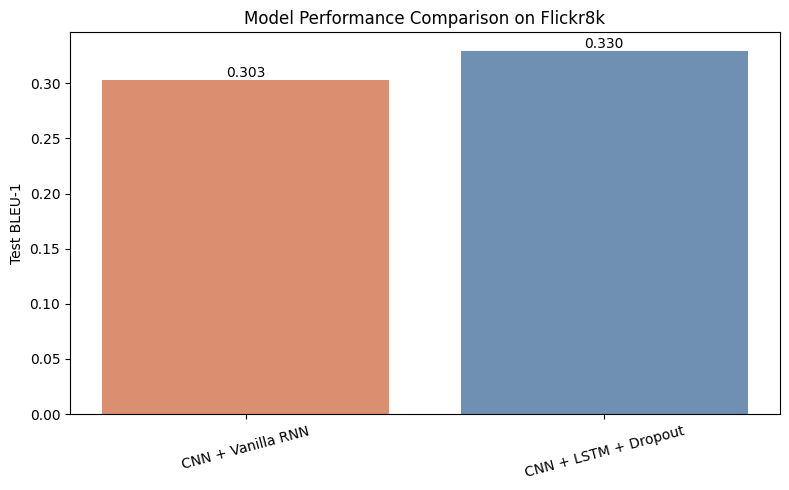

Model 1: 0.3030278599618982 0.0002469135802469136
Model 2: 0.3296720921847609 0.0004938271604938272


In [11]:
comparison = {
    "CNN + Vanilla RNN": result_rnn["test_bleu1"],
    "CNN + LSTM + Dropout": result_lstm["test_bleu1"],
}

plt.figure(figsize=(8, 5))
bars = plt.bar(list(comparison.keys()), list(comparison.values()), color=["#d98f70", "#6f8fb3"])
plt.title("Model Performance Comparison on Flickr8k")
plt.ylabel("Test BLEU-1")
plt.xticks(rotation=15)
for bar, value in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("Model 1:", result_rnn["test_bleu1"], result_rnn["test_exact_match"])
print("Model 2:", result_lstm["test_bleu1"], result_lstm["test_exact_match"])

In [12]:
pd.DataFrame(result_lstm["samples"])

,image_path,reference,prediction
0,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man lays on a bench while his dog sits by him,a man and a woman are sitting on a bench
1,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man lays on the bench to which a white dog i...,a man and a woman are sitting on a bench
2,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man sleeping on a bench outside with a white...,a man and a woman are sitting on a bench
3,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a shirtless man lies on a park bench with his dog,a man and a woman are sitting on a bench
4,/kaggle/input/datasets/adityajn105/flickr8k/Im...,man laying on bench holding leash of dog sitti...,a man and a woman are sitting on a bench
5,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man in an orange hat starring at something,a man in a blue shirt and a black hat is holdi...
6,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man wears an orange hat and glasses,a man in a blue shirt and a black hat is holdi...
7,/kaggle/input/datasets/adityajn105/flickr8k/Im...,a man with gauges and glasses is wearing a bli...,a man in a blue shirt and a black hat is holdi...


## Embedding Size / Hidden Size Analysis


Running experiment: lstm_e128_h256


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 1/2 | train_loss=3.8694 | val_loss=3.2696 | val_bleu1=0.2978 | val_exact=0.0000 | time=531.3s


  0%|          | 0/2023 [00:00<?, ?it/s]

...

Epoch 1/2 | train_loss=3.4713 | val_loss=3.0098 | val_bleu1=0.2816 | val_exact=0.0000 | time=531.6s


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 2/2 | train_loss=2.8181 | val_loss=2.8638 | val_bleu1=0.3293 | val_exact=0.0007 | time=531.6s


  0%|          | 0/254 [00:00<?, ?it/s]

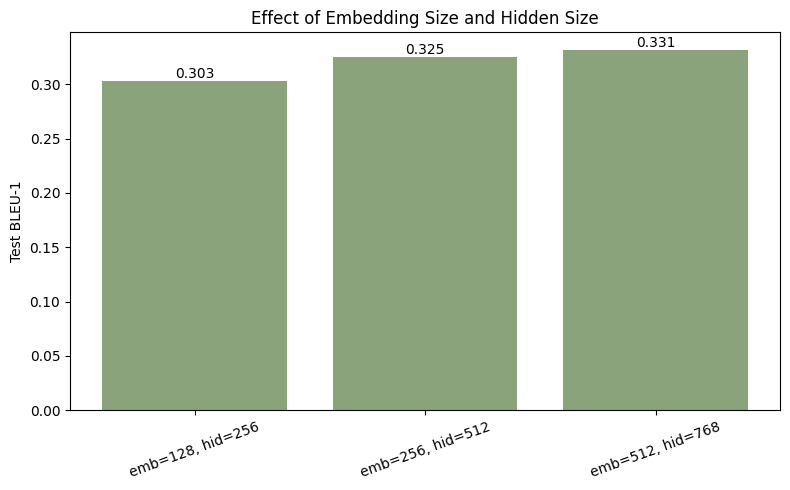

In [13]:
size_experiments = [
    ExperimentConfig("lstm_e128_h256", "lstm", 128, 256, 0.3, False, epochs=ABLATION_EPOCHS),
    ExperimentConfig("lstm_e256_h512", "lstm", 256, 512, 0.3, False, epochs=ABLATION_EPOCHS),
    ExperimentConfig("lstm_e512_h768", "lstm", 512, 768, 0.3, False, epochs=ABLATION_EPOCHS),
]

size_results = [train_experiment(cfg) for cfg in size_experiments]

size_scores = {
    f"emb={r['config']['embed_dim']}, hid={r['config']['hidden_dim']}": r["test_bleu1"]
    for r in size_results
}

plt.figure(figsize=(8, 5))
bars = plt.bar(list(size_scores.keys()), list(size_scores.values()), color="#8aa37a")
plt.title("Effect of Embedding Size and Hidden Size")
plt.ylabel("Test BLEU-1")
plt.xticks(rotation=20)
for bar, value in zip(bars, size_scores.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Fine-Tuning CNN vs Frozen CNN


Running experiment: lstm_frozen_cnn


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 1/2 | train_loss=3.6143 | val_loss=3.0786 | val_bleu1=0.2810 | val_exact=0.0005 | time=506.8s


  0%|          | 0/2023 [00:00<?, ?it/s]

...

Epoch 1/2 | train_loss=3.6177 | val_loss=3.0874 | val_bleu1=0.2829 | val_exact=0.0002 | time=680.6s


  0%|          | 0/2023 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 2/2 | train_loss=2.9320 | val_loss=2.8771 | val_bleu1=0.3259 | val_exact=0.0005 | time=668.6s


  0%|          | 0/254 [00:00<?, ?it/s]

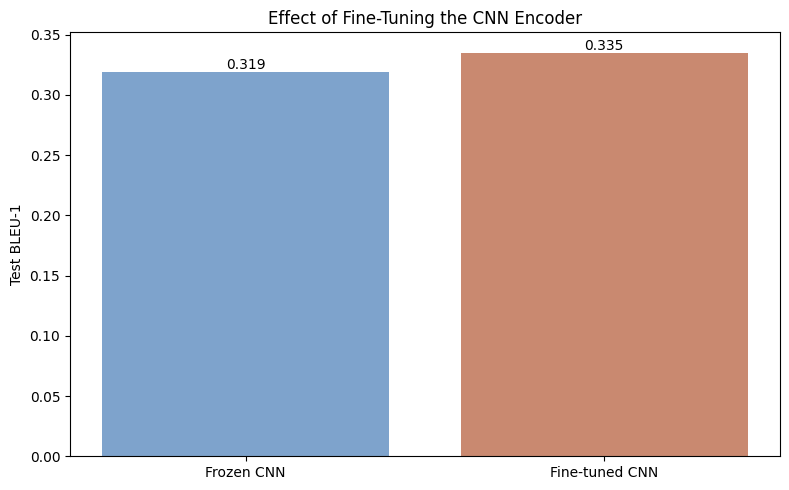

In [14]:
frozen_cfg = ExperimentConfig("lstm_frozen_cnn", "lstm", 256, 512, 0.3, False, epochs=ABLATION_EPOCHS)
finetune_cfg = ExperimentConfig("lstm_finetuned_cnn", "lstm", 256, 512, 0.3, True, epochs=ABLATION_EPOCHS, encoder_lr=1e-5)

result_frozen = train_experiment(frozen_cfg)
result_finetune = train_experiment(finetune_cfg)

finetune_scores = {
    "Frozen CNN": result_frozen["test_bleu1"],
    "Fine-tuned CNN": result_finetune["test_bleu1"],
}

plt.figure(figsize=(8, 5))
bars = plt.bar(list(finetune_scores.keys()), list(finetune_scores.values()), color=["#7ea3cc", "#c98970"])
plt.title("Effect of Fine-Tuning the CNN Encoder")
plt.ylabel("Test BLEU-1")
for bar, value in zip(bars, finetune_scores.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [15]:
all_results = {
    "model_1_cnn_vanilla_rnn": {
        "config": result_rnn["config"],
        "test_loss": result_rnn["test_loss"],
        "test_acc": result_rnn["test_acc"],
        "test_bleu1": result_rnn["test_bleu1"],
        "test_exact_match": result_rnn["test_exact_match"],
    },
    "model_2_cnn_lstm_dropout": {
        "config": result_lstm["config"],
        "test_loss": result_lstm["test_loss"],
        "test_acc": result_lstm["test_acc"],
        "test_bleu1": result_lstm["test_bleu1"],
        "test_exact_match": result_lstm["test_exact_match"],
    },
    "embedding_hidden_analysis": [
        {
            "config": result["config"],
            "test_bleu1": result["test_bleu1"],
            "test_exact_match": result["test_exact_match"],
        }
        for result in size_results
    ],
    "cnn_finetune_analysis": {
        "frozen": {
            "config": result_frozen["config"],
            "test_bleu1": result_frozen["test_bleu1"],
            "test_exact_match": result_frozen["test_exact_match"],
        },
        "fine_tuned": {
            "config": result_finetune["config"],
            "test_bleu1": result_finetune["test_bleu1"],
            "test_exact_match": result_finetune["test_exact_match"],
        },
    },
}

with open("flickr8k_q4_results_runtime_safe.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print("Saved results to flickr8k_q4_results_runtime_safe.json")

Saved results to flickr8k_q4_results_runtime_safe.json
